# 12.16 說話和打字，如何保留同一段對話？


先打字說「接下來請用兩點回答」，接著用語音提出「我的銀行 App 打不開」這個需求，再打字說「改成一句」。我們希望中間的回覆分成兩點，最後的回覆縮成一句，而且仍然在回應 App 的問題。換輸入方式，不應把原先的格式要求或談到的主題清掉。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

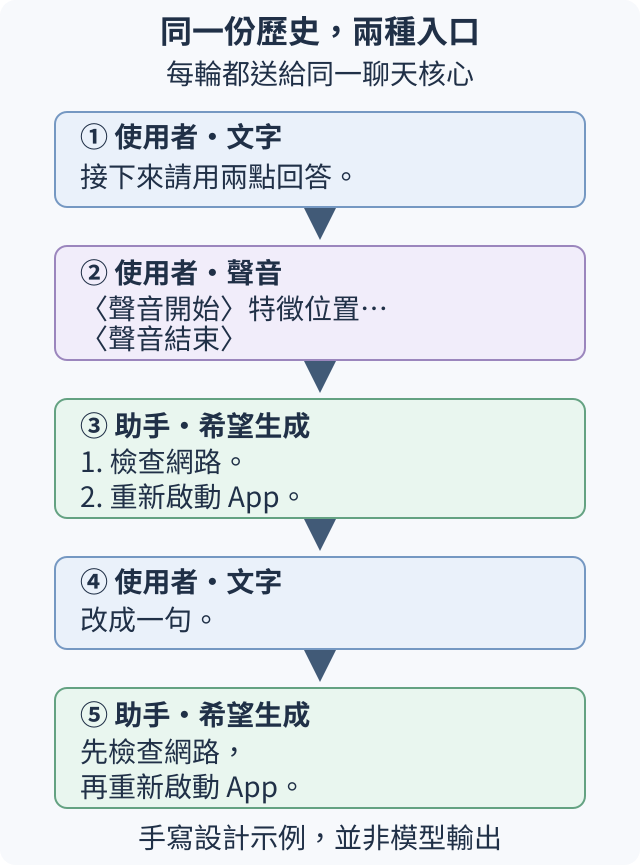

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/new-12.16-shared-history.svg")))

圖中對話是手寫設計例。開頭的語音問句供讀者理解需求；模型訊息保留聲音特徵，不把旁註文字當逐字稿送入。

上一節讓自行訓練的語音入口，把聲音變成核心能接收的一組特徵位置。這一節沿用它，新增的是「把各輪保存在同一份歷史」。文字那輪有使用者角色和文字位置；聲音那輪也有使用者角色，內容則是帶起訖標記的聲音特徵位置。起訖標記告訴模型這段輸入從哪裡開始、到哪裡結束，不提供它的文字答案。

圖中的「聲音開始／聲音結束」是教學標記，不規定實作一定使用這些字面名稱。在真正的模型輸入中，特徵位置放的是語音入口算出的數字，並非把「聲音特徵」四個字打給模型。這和圖片特徵接進序列的觀念相同：入口不同，核心接收與利用的仍是一段排列好的輸入。

處理語音那輪時，核心應一起讀到先前的文字要求「用兩點回答」。所以希望答覆是「1. 檢查網路。2. 重新啟動 App。」這段助手答覆也要加入歷史，下一輪才知道自己剛剛說過什麼。當使用者再說「改成一句」，核心收到的是整段已保留的對話，加上這個新要求，可以知道「改」的是前一個答覆，而不是突然換了一個新問題。

共享歷史需要兩件事合作。系統要把角色、各輪內容與先後順序保存並送入；模型也要學會使用它們。只有保存記錄，不能保證模型會遵守格式；如果模型沒有收到前文，再強的語音入口也補不出已被清掉的要求。訓練示範因此需要包含這種跨輪對話，而不只是一段聲音對一段固定答案。

可以保持同一個語音需求，只改第一輪要求：一次用「兩點」，一次用「一句」。檢查主題是否相同、格式是否不同，就能看出舊要求有沒有參與回答。再保留「改成一句」，換成另一種先前需求，檢查最後一句是否跟著換主題。這兩個對照分別讓格式線索與主題線索發揮作用，不用把兩路回答逐字相同當作唯一判準。

前面的 12.14 已介紹另一種共享方式：語音先經 ASR 變成逐字稿，再把文字寫進共同歷史。本節改用 12.15 的直接特徵入口，所以語音那輪保留的是聲音特徵位置。兩條路都要保存對話，差別在於核心收到的內容；不能畫成聲音特徵路線，實際卻先用隱藏 ASR 換成正確文字。

練習把第一輪改成「請用一句回答」，最後一輪改成「改成兩點」，語音需求保持相同。希望答覆應在哪一輪改成兩點？核心需要保留哪些訊息，才知道修改的是同一個 App 問題？

<details>
<summary>前文與設計範圍</summary>

[12.14](https://birdhackor.github.io/tiny-perceptron-vlm/12.14.html)保留 ASR 逐字稿路線；[12.15](https://birdhackor.github.io/tiny-perceptron-vlm/12.15.html)說明有限需求的直接聲音入口。這裡接續[7.1 的角色與對話表示](https://birdhackor.github.io/tiny-perceptron-vlm/7.1.html)，只把其中一輪的內容換成聲音特徵。

本節沒有取用特定公開錄音；語音來源與自訓練元件的範圍見[主線來源筆記](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-revision-20261005/sources/selftrained-capstone.md)。

</details>
